--- Program Pengolahan Citra Frekuensi & Wavelet ---


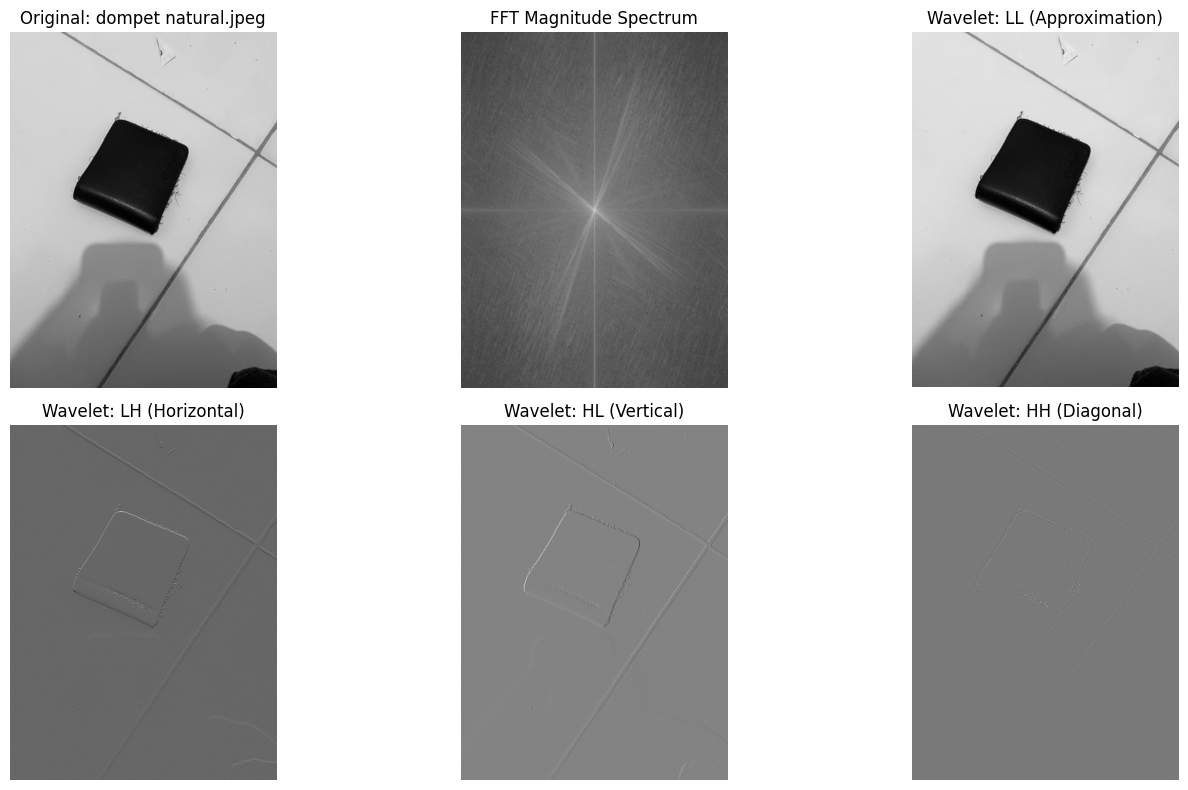


Proses selesai dengan sukses!


In [6]:
import numpy as np
import cv2
import pywt
import os
from matplotlib import pyplot as plt

# 1. FFT Implementation
def process_fft(img):
    if img is None: return None, None
    f = np.fft.fft2(img)
    fshift = np.fft.fftshift(f)
    magnitude_spectrum = 20 * np.log(np.abs(fshift) + 1)
    return fshift, magnitude_spectrum

# 2. Wavelet Implementation
def process_wavelet(img):
    if img is None: return None, None, None, None
    coeffs2 = pywt.dwt2(img, 'haar')
    LL, (LH, HL, HH) = coeffs2
    return LL, LH, HL, HH

# --- INPUT USER ---
print("--- Program Pengolahan Citra Frekuensi & Wavelet ---")
nama_file = input("Masukkan nama file foto (contoh: dompet efek.jpg): ")

# Cek apakah file ada di folder
if not os.path.exists(nama_file):
    print(f"Error: File '{nama_file}' tidak ditemukan di folder aktif!")
else:
    # Load gambar
    img = cv2.imread(nama_file, 0)
    
    if img is None:
        print("Gagal membaca gambar. Pastikan format file didukung (jpg/png).")
    else:
        # Proses FFT
        fshift, mag = process_fft(img)
        
        # Proses Wavelet
        LL, LH, HL, HH = process_wavelet(img)
        
        # --- VISUALISASI ---
        plt.figure(figsize=(15, 8))
        
        # Gambar Asli
        plt.subplot(231)
        plt.imshow(img, cmap='gray')
        plt.title(f'Original: {nama_file}')
        plt.axis('off')
        
        # FFT Spectrum
        plt.subplot(232)
        plt.imshow(mag, cmap='gray')
        plt.title('FFT Magnitude Spectrum')
        plt.axis('off')
        
        # Wavelet Approximation (LL)
        plt.subplot(233)
        plt.imshow(LL, cmap='gray')
        plt.title('Wavelet: LL (Approximation)')
        plt.axis('off')
        
        # Wavelet Details
        plt.subplot(234)
        plt.imshow(LH, cmap='gray')
        plt.title('Wavelet: LH (Horizontal)')
        plt.axis('off')
        
        plt.subplot(235)
        plt.imshow(HL, cmap='gray')
        plt.title('Wavelet: HL (Vertical)')
        plt.axis('off')
        
        plt.subplot(236)
        plt.imshow(HH, cmap='gray')
        plt.title('Wavelet: HH (Diagonal)')
        plt.axis('off')
        
        plt.tight_layout()
        plt.show()
        
        print("\nProses selesai dengan sukses!")